<a href="https://colab.research.google.com/github/nidomarinho-Tito/explora-o-e-an-lise-de-dados-de-vendas/blob/main/notebooks/dataview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DataView - Análise de Vendas

Autor: Nivaldo Marinho

Mini Projeto Avaliativo


Exploração e Análise de Dados de Vendas

In [ ]:
import pandas as pd
import numpy as np
import random, os, re, json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
def gerar_dataset_vendas(n_registros=1000, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse']
    precos = {'Notebook': 3500, 'Smartphone': 2200, 'Tablet': 1800, 'Monitor': 1200, 'Teclado': 250, 'Mouse': 120}
    categorias = {"Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares", "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos"}
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]
    data_inicio = datetime(2024, 1, 1)
    dados = []
    for i in range(n_registros):
        produto = random.choice(produtos)
        cliente = random.choice(clientes)
        regiao = random.choice(regioes)
        quantidade = random.randint(1, 5)
        preco = precos[produto]
        if random.random() < 0.10: quantidade = None
        if random.random() < 0.08: preco = None
        if random.random() < 0.05:
            data_venda = "31/02/2024"
        else:
            dias = random.randint(0, 365)
            data_venda = (data_inicio + timedelta(days=dias)).strftime("%Y-%m-%d")
        produto_sujo = " " + produto + " "
        cliente_sujo = "  " + cliente + "  "
        regiao_sujo = regiao + " "
        registro = {"id_venda": i + 1, "data_venda": data_venda, "cliente": cliente_sujo, "produto": produto_sujo, "categoria": categorias[produto], "regiao": regiao_sujo, "quantidade": quantidade, "preco_unitario": preco}
        dados.append(registro)
    df = pd.DataFrame(dados)
    return df

os.makedirs("data/raw", exist_ok=True)
df_bruto = gerar_dataset_vendas(n_registros=1000, seed=42)
df_bruto.to_csv("data/raw/vendas.csv", index=False)
print(f"Dataset gerado com {len(df_bruto)}:registros")
print(df_bruto.head())

Dataset gerado com 1000:registros
   id_venda  data_venda          cliente       produto     categoria  \
0         1  2024-10-06    Cliente_004          Mouse    Periféricos   
1         2  2024-01-14    Cliente_019       Notebook   Computadores   
2         3  2024-01-04    Cliente_007        Teclado    Periféricos   
3         4  2024-02-22    Cliente_023     Smartphone      Celulares   
4         5  2024-08-23    Cliente_013       Notebook   Computadores   

          regiao  quantidade  preco_unitario  
0       Sudeste          3.0           120.0  
1  Centro-Oeste          NaN          3500.0  
2         Norte          4.0           250.0  
3  Centro-Oeste          3.0          2200.0  
4       Sudeste          3.0          3500.0  


In [ ]:


def inspecionar_dados(df):
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape (Linhas, Colunas): {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print("\nEstatísticas descritivas:")

    return df.describe(include="all")

In [ ]:
def limpar_strings_regex(df, colunas):
    df = df.copy()
    for col in colunas:
        df[col] = df[col].apply(lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s)
    return df

def limpar_dados(df):
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)
    print("=== RELATÓRIO REALIZADO LIMPEZA ===")
    for k, v in relatorio.items():
        print(f"  {k}: {v}")
    return df, relatorio

df_v1, relatorio = limpar_dados(df_bruto)
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)
df_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)
print("\nv1a salva em data/processed/v1_com outliers/")
print(df_v1.head())

# Corrigido o nome da variável de df_vendas para df_bruto e removida a indentação incorreta
df_limpo, relatorio_limpeza = limpar_dados(df_bruto)

print("\nPrimeiros registos após limpeza:")
print(df_limpo.head())

=== RELATÓRIO REALIZADO LIMPEZA ===
  datas_invalidas_removidas: 36
  linhas_nulas_removidas: 162
  registros_iniciais: 1000
  registros_finais: 802
  registros_removidos_total: 198

v1a salva em data/processed/v1_com outliers/
   id_venda data_venda      cliente     produto     categoria        regiao  \
0         1 2024-10-06  Cliente_004       Mouse   Periféricos       Sudeste   
2         3 2024-01-04  Cliente_007     Teclado   Periféricos         Norte   
3         4 2024-02-22  Cliente_023  Smartphone     Celulares  Centro-Oeste   
4         5 2024-08-23  Cliente_013    Notebook  Computadores       Sudeste   
5         6 2024-07-04  Cliente_004     Teclado   Periféricos  Centro-Oeste   

   quantidade  preco_unitario  
0           3           120.0  
2           4           250.0  
3           3          2200.0  
4           3          3500.0  
5           1           250.0  
=== RELATÓRIO REALIZADO LIMPEZA ===
  datas_invalidas_removidas: 36
  linhas_nulas_removidas: 162
  regis

In [ ]:
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    df = df.copy()
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        print(f"  {col}: {n_out} outliers encontrados")
        if metodo == 'remover':
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
    return df

df_v1_tmp = df_v1.copy()
df_v1_tmp["receita_total"] = df_v1_tmp["quantidade"] * df_v1_tmp["preco_unitario"]
df_v2 = tratar_outliers(df_v1_tmp, colunas=['quantidade', 'receita_total'], metodo='remover')
df_v2 = df_v2.drop(columns=['receita_total'])

print(f"\nv1 = {len(df_v1)} (linhas com outliers)")
print(f"v2 = {len(df_v2)} (linhas com outliers removidos)")
print(f"Diferença = {len(df_v1) - len(df_v2)} linhas removidas")

os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)
df_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
print("\nv2 salva em data/processed/v2_outliers_tratado/")

  quantidade: 0 outliers encontrados
  receita_total: 26 outliers encontrados

v1 = 802 (linhas com outliers)
v2 = 776 (linhas com outliers removidos)
Diferença = 26 linhas removidas

v2 salva em data/processed/v2_outliers_tratado/


In [ ]:
def criar_colunas_derivadas(df):
    df = df.copy()
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"] = df["data_venda"].dt.year
    condicoes = [df["receita_total"] < 500, (df["receita_total"] >= 500) & (df["receita_total"] < 5000), df["receita_total"] >= 5000]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")
    print("\nCOLUNAS NOVAS CRIADAS")
    print(df[["data_venda", "receita_total", "mes", "trimestre", "faixa_receita_item"]].head())
    return df

df = criar_colunas_derivadas(df_v2)
df[["data_venda", "receita_total", "mes", "trimestre",
"faixa_receita_item"]].head()



COLUNAS NOVAS CRIADAS
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-10-06          360.0   10        Q4        Baixo Valor
2 2024-01-04         1000.0    1        Q1        Médio Valor
3 2024-02-22         6600.0    2        Q1         Alto Valor
4 2024-08-23        10500.0    8        Q3         Alto Valor
5 2024-07-04          250.0    7        Q3        Baixo Valor


,data_venda,receita_total,mes,trimestre,faixa_receita_item
0,2024-10-06,360.0,10,Q4,Baixo Valor
2,2024-01-04,1000.0,1,Q1,Médio Valor
3,2024-02-22,6600.0,2,Q1,Alto Valor
4,2024-08-23,10500.0,8,Q3,Alto Valor
5,2024-07-04,250.0,7,Q3,Baixo Valor


In [ ]:
def calcular_metricas(df):
    metricas = {}
    metricas["por_mes"] = df.groupby("mes").agg(receita_total=("receita_total", "sum"), quantidade=("quantidade", "sum"), n_vendas=("id_venda", "count")).reset_index().sort_values("mes")
    metricas["top_produtos"] = df.groupby("produto")["receita_total"].sum().sort_values(ascending=False).head(5).reset_index()
    metricas["por_categoria"] = df.groupby("categoria")["receita_total"].sum().reset_index().sort_values("receita_total", ascending=False)
    metricas["por_regiao"] = df.groupby("regiao").agg(receita_total=("receita_total", "sum"), media_ticket=("receita_total", "mean")).reset_index().sort_values("receita_total", ascending=False)

    for nome, tabela in metricas.items():
        print(f"\n=== {nome.upper().replace('_', ' ')} ===")
        print(tabela.to_string(index=False))
    return metricas

metricas = calcular_metricas(df)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       177280.0         127        45
   2       262420.0         188        64
   3       365680.0         228        84
   4       188890.0         140        46
   5       316960.0         193        61
   6       240890.0         164        56
   7       239080.0         192        64
   8       303290.0         186        70
   9       320780.0         221        75
  10       235350.0         175        63
  11       340850.0         212        70
  12       321190.0         221        78

=== TOP PRODUTOS ===
   produto  receita_total
  Notebook      1165500.0
Smartphone       981200.0
    Tablet       597600.0
   Monitor       418800.0
   Teclado       106000.0

=== POR CATEGORIA ===
   categoria  receita_total
Computadores      1584300.0
   Celulares      1578800.0
 Periféricos       149560.0

=== POR REGIAO ===
      regiao  receita_total  media_ticket
    Nordeste       701390.0   4525.096774
     Sudeste       6

In [ ]:
def segmentar_clientes(df):
    clientes_df = df.groupby("cliente")["receita_total"].sum().reset_index()
    clientes_df.columns = ["cliente", "total_gasto"]
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(lambda g: "Ouro" if g > 140000.0 else ("Prata" if g >= 5000 else "Bronze"))
    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)
    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição das medalhas:\n{clientes_df['segmento'].value_counts()}")
    return clientes_df

clientes = segmentar_clientes(df)
clientes.head()


=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
    cliente  total_gasto segmento
Cliente_013     146660.0     Ouro
Cliente_015     145210.0     Ouro
Cliente_012     142470.0     Ouro
Cliente_007     139720.0    Prata
Cliente_011     135870.0    Prata
Cliente_025     134440.0    Prata
Cliente_008     132060.0    Prata
Cliente_006     132010.0    Prata
Cliente_024     127980.0    Prata
Cliente_023     115890.0    Prata

Distribuição das medalhas:
segmento
Prata    27
Ouro      3
Name: count, dtype: int64


,cliente,total_gasto,segmento
12,Cliente_013,146660.0,Ouro
14,Cliente_015,145210.0,Ouro
11,Cliente_012,142470.0,Ouro
6,Cliente_007,139720.0,Prata
10,Cliente_011,135870.0,Prata


In [ ]:
def calcular_estatisticas_numpy(df):
    receitas = df["receita_total"].to_numpy()
    media = np.mean(receitas)

    stats = {
        "media": media,
        "mediana": np.median(receitas),
        "desvio_padrao": np.std(receitas),
        "percentil_90": np.percentile(receitas, 90),
        "total": float(np.sum(receitas)),
"p25": float(np.percentile(receitas, 25)),
"p75": float(np.percentile(receitas, 75)),

    }

    receitas_pct = (receitas / receitas.sum()) * 100
    print(f"Participação das 5 maiores vendas no total: {np.sort(receitas_pct)[-5:].round(2)}%")

    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    print("\n=== ESTATÍSTICAS COM NUMPY ===")
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f" {k}: {v} vendas")
        else:
            print(f" {k}: R$ {v:.2f}")

    return stats

stats_resultado = calcular_estatisticas_numpy(df)

Participação das 5 maiores vendas no total: [0.42 0.42 0.42 0.42 0.42]%

=== ESTATÍSTICAS COM NUMPY ===
 media: R$ 4268.89
 mediana: R$ 3500.00
 desvio_padrao: R$ 4012.81
 percentil_90: R$ 10500.00
 total: R$ 3312660.00
 p25: R$ 750.00
 p75: R$ 7000.00
 acima_da_media: 326 vendas


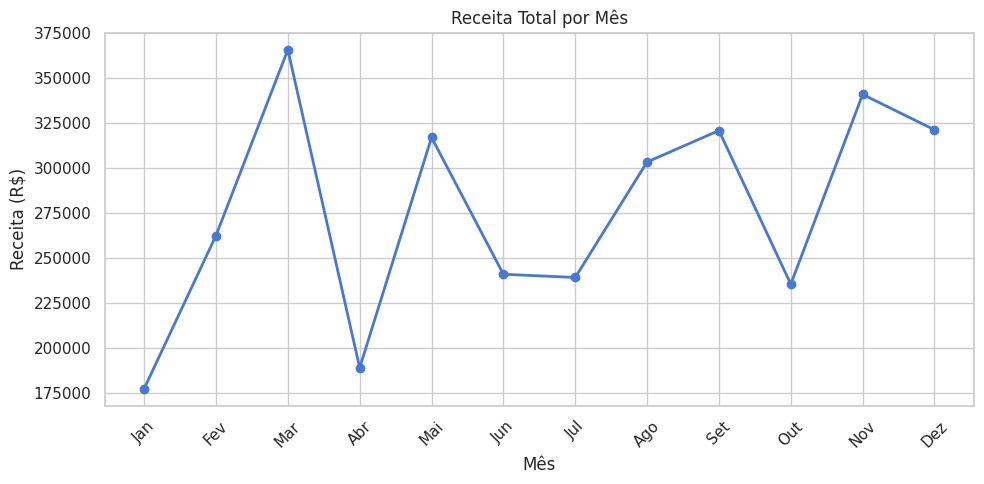

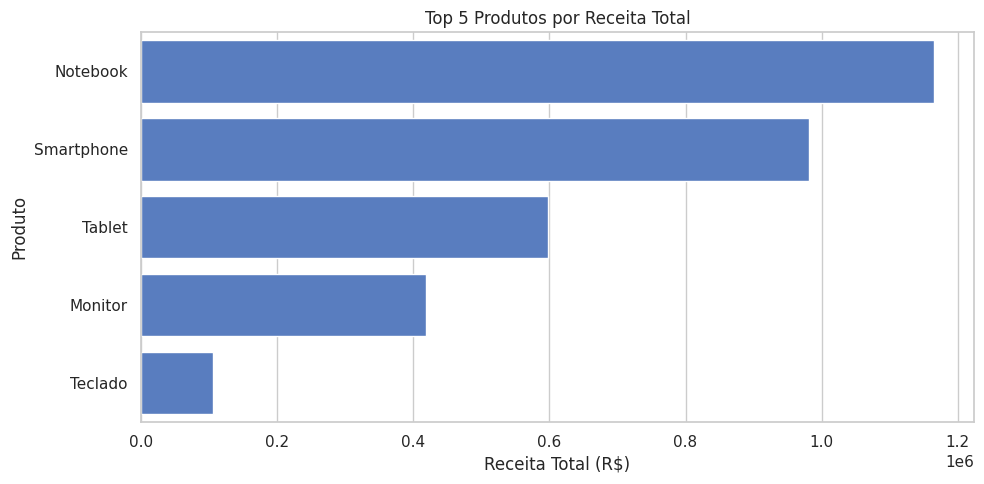

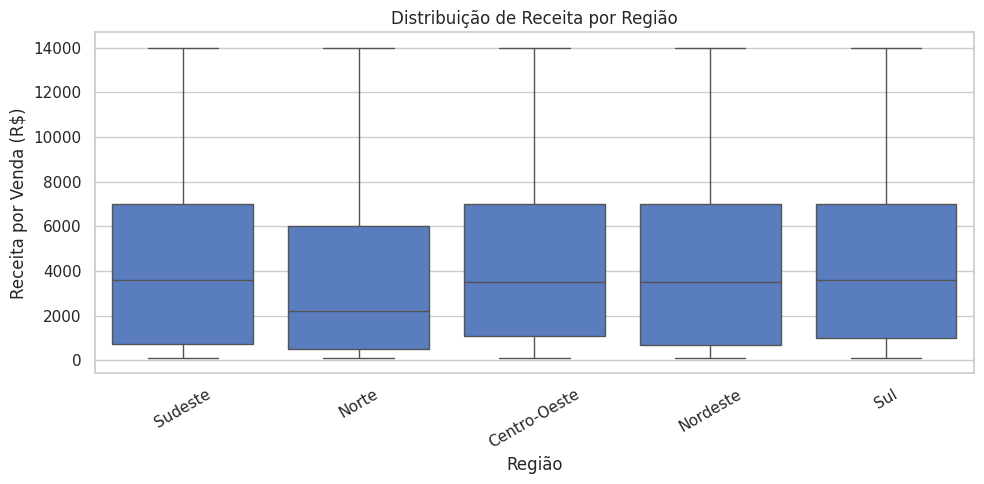

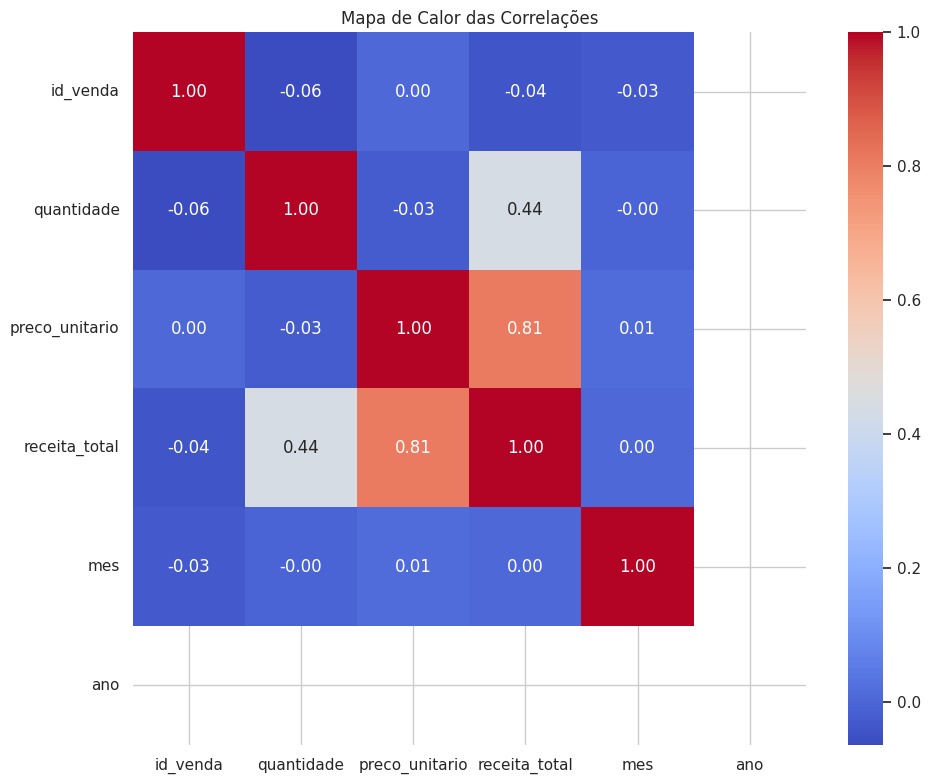

4 gráficos salvos em: outputs/graficos


In [ ]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")
    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

    # Gráfico 1: Linha (Vendas pelo tempo)
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 2: Barras (Top 5 produtos)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=metricas["top_produtos"], y="produto", x="receita_total", ax=ax)
    ax.set_title("Top 5 Produtos por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 3: Boxplot (Mostra se as vendas são parecidas ou variadas por região)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao", y="receita_total", ax=ax)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/distribuicao_regiao.png", dpi=120)
    plt.show()
    plt.close()

    # Gráfico 4: Heatmap (Corrigida a indentação aqui)
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = df.corr(numeric_only=True)  # calcula correlação apenas de colunas numéricas
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
    ax.set_title("Mapa de Calor das Correlações")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/heatmap_correlacoes.png", dpi=120)
    plt.show()
    plt.close()

    print(f"4 gráficos salvos em: {output_dir}")

gerar_visualizacoes(df, metricas)

In [ ]:
import pandas as pd

# 1. Função encapsulada com docstring e retorno explícito
def limpar_dados_nulos(df, colunas_obrigatorias):
    """
    Sua função é remover linhas que contenham valores nulos nas colunas obrigatórias especificadas.
    Pode ser reutilizada para gerar as versões v1 e v2 do dataset.
    Parâmetros:
    df (pd.DataFrame): O DataFrame a ser limpo.
    colunas_obrigatorias (list): Lista com os nomes das colunas a serem verificadas.
    Retorna:
    pd.DataFrame: DataFrame limpo sem valores nulos nas colunas alvo.
    """
    df_limpo = df.dropna(subset=colunas_obrigatorias).copy()
    return df_limpo

# 2. Requisito Bônus: Função de Ordem Superior
def aplicar_transformacao(df, coluna, funcao_transformacao):
    """
    Aplica uma função de transformação (callback) a uma coluna do DataFrame.
    Esta é uma função de ordem superior porque recebe outra função como parâmetro.
    Segue os parâmetros:
    df (pd.DataFrame): O DataFrame alvo.
    coluna (str): O nome da coluna que será transformada.
    funcao_transformacao (callable): Função (como uma lambda) aplicada a cada valor.
    Retorna:
    pd.DataFrame: DataFrame com a nova coluna transformada.
    """
    df_temp = df.copy()
    nova_coluna = f"{coluna}_transformado"
    # Aplica a função recebida por parâmetro na coluna especificada
    df_temp[nova_coluna] = df_temp[coluna].apply(funcao_transformacao)
    return df_temp

    """
    Exemplo abaixo
    """
    # DataFrame de exemplo simulando suas vendas
dados_simulados = {
    'cliente': ['Cliente A', 'Cliente B', 'Cliente C', 'Cliente D'],
    'receita_total': [1200.50, 7500.00, None, 6200.00]
}
df_vendas = pd.DataFrame(dados_simulados)

print("--- 1. DataFrame Original (Com dados sujos) ---")
display(df_vendas)

# Reutilizando a função de limpeza (cumprindo a regra de reutilização)
df_limpo = limpar_dados_nulos(df_vendas, ['receita_total'])
print("\n--- 2. Após Limpeza de Nulos ---")
display(df_limpo)

# Utilizando a função de ordem superior passando uma função LAMBDA como callback
# A lambda verifica: se a receita for maior que 5000 é "Alto", senão "Normal"
df_demo = aplicar_transformacao(
    df_limpo,
    "receita_total",
    lambda x: "Alto" if x > 5000 else "Normal"
)

print("\n=== 3. EXEMPLO DA RF10: Classificação por ticket usando Lambda ===")
display(df_demo[['cliente', 'receita_total', 'receita_total_transformado']])

--- 1. DataFrame Original (Com dados sujos) ---


,cliente,receita_total
0,Cliente A,1200.5
1,Cliente B,7500.0
2,Cliente C,NaN
3,Cliente D,6200.0



--- 2. Após Limpeza de Nulos ---


,cliente,receita_total
0,Cliente A,1200.5
1,Cliente B,7500.0
3,Cliente D,6200.0



=== 3. EXEMPLO DA RF10: Classificação por ticket usando Lambda ===


,cliente,receita_total,receita_total_transformado
0,Cliente A,1200.5,Normal
1,Cliente B,7500.0,Alto
3,Cliente D,6200.0,Alto


In [ ]:
import json
import os
import numpy as np

def exportar_resultados(metricas, clientes, stats):
    os.makedirs("outputs", exist_ok=True)
    metricas["por_mes"].to_csv("outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig")
    clientes.to_csv("outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig")
    print("CSV exportado: outputs/metricas_por_mes.csv")

    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = "outputs/estatisticas_gerais.json"
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"Arquivo JSON criado: {caminho_json}")

    # Lê de volta para retornar o conteúdo
    with open(caminho_json, encoding="utf-8") as f:
        lido_interno = json.load(f)
    return lido_interno

# 1. Primeiro definimos os dados necessários
stats_para_exportar = {"media": float(np.mean(df["receita_total"].to_numpy()))}

# 2. Chamamos a função e guardamos o retorno
resultado_lido = exportar_resultados(metricas, clientes, stats_para_exportar)

# 3. Agora podemos imprimir o que foi lido
print("\nJSON lido de volta para confirmação:")
print(json.dumps(resultado_lido, indent=2, ensure_ascii=False))

CSV exportado: outputs/metricas_por_mes.csv
Arquivo JSON criado: outputs/estatisticas_gerais.json

JSON lido de volta para confirmação:
{
  "media": 4268.89
}


In [ ]:
import os

df_final = df_v2.copy()
caminho_pasta = 'data/final'
os.makedirs(caminho_pasta, exist_ok=True)
caminho_ficheiro = f'{caminho_pasta}/dataset_vendas_final.csv'
df_final.to_csv(caminho_ficheiro, index=False)

print(f"✅ Análise consolidada com sucesso!")
print(f"O dataset final foi guardado em: {caminho_ficheiro}")

display(df_final.head())

✅ Análise consolidada com sucesso!
O dataset final foi guardado em: data/final/dataset_vendas_final.csv


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-10-06,Cliente_004,Mouse,Periféricos,Sudeste,3,120.0
2,3,2024-01-04,Cliente_007,Teclado,Periféricos,Norte,4,250.0
3,4,2024-02-22,Cliente_023,Smartphone,Celulares,Centro-Oeste,3,2200.0
4,5,2024-08-23,Cliente_013,Notebook,Computadores,Sudeste,3,3500.0
5,6,2024-07-04,Cliente_004,Teclado,Periféricos,Centro-Oeste,1,250.0
